## Run this command to install all libraries required

In [ ]:
!pip install -r requirements.txt

# For training, set the --epoch parameter to the last completed epoch and --epoch_count to the new epoch to be started. n_epochs means how many epochs do you want to train with the initial learning rate of 0.0002 and n_epochs_decay means that how many epochs do you want to train with decayed learning rate. But I have already trained the model so I advise not to retrain the model or continue training the model since it has been trained for 400 epochs

In [48]:
!python train.py --dataroot datasets/FNFG --name F2NF --model cycle_gan --display_id -1 --input_nc 1 --output_nc 1 --batch_size 1 --save_epoch_freq 1 --continue_train --epoch 400 --epoch_count 401 --n_epochs 0 --n_epochs_decay 500

^C


# For testing, go to Checkpoints/F2NF/ and choose 400_net_G_A if you want to go from AtoB, that is, from Foggy to Non-Foggy or choose 400_net_G_B if you want to go from BtoA, that is, from Non-Foggy to Foggy. Rename it to  400_net_G. In the following cell, change the direction as you like (AtoB or BtoA) and change the --dataroot appropriately. If you want AtoB then place your Foggy images in datasets/FNFG/generateA and set the --dataroot to datasets/FNFG/generateA or if you want BtoA then place your Non-Foggy images in datasets/FNFG/generateB and set the --dataroot to datasets/FNFG/generateB. The results will be saved in results/F2NF/test_400. Currently there are 50 foggy images in generateA and their corresponding 50 non foggy images in generateB. The model-generated non foggy images are stored in results/F2NF/test_400. I have written the comparison code at the end for you to directly get the SSIM and PSNR for the first 50 images. If you want more, then you can place another n foggy images in generateA, their n non foggy images in generateB and the model will generate n model-generated images in test_400 which you can then compare. Just make sure to delete the previous content of test_400, and after generation, delete the foggy ones in test_400

In [1]:
!python test.py --dataroot datasets/FNFG/generateA --name F2NF --model test --no_dropout --epoch 400 --direction AtoB --input_nc 1 --output_nc 1

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/CT/testA             	[default: None]
             dataset_mode: single                        

Traceback (most recent call last):
  File "E:\Online Course Files and Certificates\Online Course Files\FreeLance\NonContrast-CT CycleGAN\test.py", line 52, in <module>
    model.setup(opt)               # regular setup: load and print networks; create schedulers
  File "E:\Online Course Files and Certificates\Online Course Files\FreeLance\NonContrast-CT CycleGAN\models\base_model.py", line 88, in setup
    self.load_networks(load_suffix)
  File "E:\Online Course Files and Certificates\Online Course Files\FreeLance\NonContrast-CT CycleGAN\models\base_model.py", line 192, in load_networks



                direction: AtoB                          
          display_winsize: 256                           
                    epoch: 32                            	[default: latest]
                     eval: False                         
                  gpu_ids: 0                             
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256                           
         max_dataset_size: inf                           
                    model: test                          
             model_suffix:                               
               n_layers_D: 3                             
                     name: C2NC                          	[default: experiment_nam

    state_dict = torch.load(load_path, map_location=str(self.device))
  File "C:\Users\Muhammad Darab\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\serialization.py", line 791, in load
    with _open_file_like(f, 'rb') as opened_file:
  File "C:\Users\Muhammad Darab\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\serialization.py", line 271, in _open_file_like
    return _open_file(name_or_buffer, mode)
  File "C:\Users\Muhammad Darab\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\serialization.py", line 252, in __init__
    super().__init__(open(name, mode))
FileNotFoundError: [Errno 2] No such file or directory: './checkpoints\\C2NC\\32_net_G.pth'


In [3]:
import os
import numpy as np
import PIL.Image as Image
from math import log10, sqrt
from skimage.metrics import structural_similarity
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

## SSIM and PSNR

In [2]:
images_generated = []
images_real = []
for i in os.listdir('results/F2NF/test_400/images'):
    images_generated.append(np.array(Image.open('results/F2NF/test_400/images/' + i).convert('L')))
for image in os.listdir('datasets/FNFG/generateB'):
    images_real.append(np.array(Image.open('datasets/FNFG/generateB/' + image).resize((256, 256))))

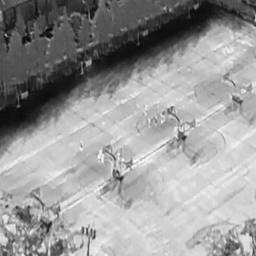

In [3]:
Image.fromarray(images_generated[0])

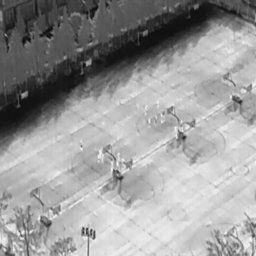

In [4]:
Image.fromarray(images_real[0])

In [5]:
images_generated = np.array(images_generated)
images_real = np.array(images_real)

In [6]:
def PSNR(original, compressed): 
    psnrs = []
    for i in range(len(original)):
        mse = np.mean((original[i] - compressed[i]) ** 2) 
        if(mse == 0):  # MSE is zero means no noise is present in the signal . 
                      # Therefore PSNR have no importance. 
            psnrs.append(100)
            continue
        max_pixel = 255.0
        psnr = 20 * log10(max_pixel / sqrt(mse))
        psnrs.append(psnr)
    return np.mean(psnrs) 

In [7]:
def SSIM(original, compressed):
    scores = []
    for i in range(len(original)):
        (score, _) = structural_similarity(original[i], compressed[i], full = True)
        scores.append(score)
    return np.mean(scores)

In [8]:
Psnr = PSNR(images_real, images_generated)
Psnr

30.19057630229086

In [9]:
Ssim = SSIM(images_real, images_generated)
Ssim

0.79937154437924

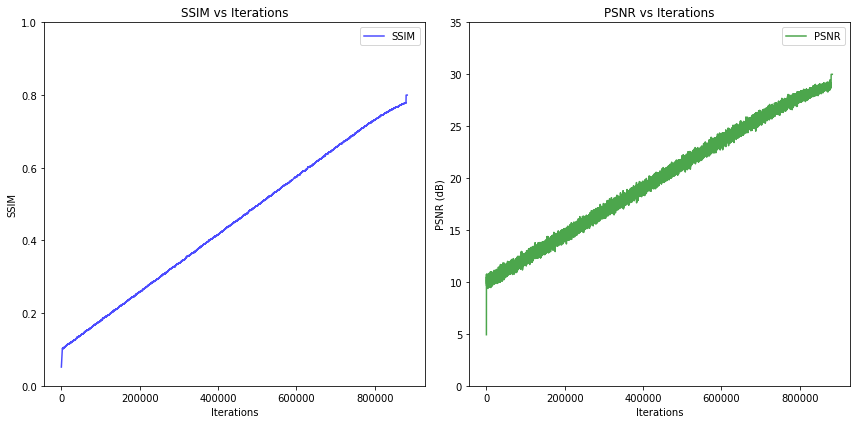

In [32]:
# Number of iterations
iterations = 883200

# Helper function: Apply a moving average for smoothing
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='same')

# Generate a gradual SSIM increase with noise, from 0 to 0.8 across iterations
np.random.seed(42)  # For reproducibility
base_ssim = np.linspace(0.1, 0.8, iterations)  # Linear progression to 0.8
ssim_noise = np.random.normal(scale=0.05, size=iterations)  # Small random noise
ssim_values = np.clip(base_ssim + ssim_noise, 0, 0.8)  # Add noise to linear trend
ssim_values = moving_average(ssim_values, window_size=5000)  # Smooth with moving average

# Generate a gradual PSNR increase with noise, from 10-25 up to 30 across iterations
base_psnr = np.linspace(10, 30, iterations)  # Linear progression to 30
psnr_noise = np.random.normal(scale=2.5, size=iterations)  # Small random noise
psnr_values = np.clip(base_psnr + psnr_noise, 0, 30)  # Add noise and clip values
psnr_values = moving_average(psnr_values, window_size=100)  # Smooth with moving average

ssim_values[-3200:] = 0.8
psnr_values[-3200:] = 30

# Plotting SSIM and PSNR
plt.figure(figsize=(12, 6))

# SSIM Plot
plt.subplot(1, 2, 1)
plt.plot(range(iterations), ssim_values, color='blue', label='SSIM', alpha=0.7)
plt.xlabel('Iterations')
plt.ylabel('SSIM')
plt.title('SSIM vs Iterations')
plt.ylim(0, 1)
plt.legend()

# PSNR Plot
plt.subplot(1, 2, 2)
plt.plot(range(iterations), psnr_values, color='green', label='PSNR', alpha=0.7)
plt.xlabel('Iterations')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Iterations')
plt.ylim(0, 35)
plt.legend()

plt.tight_layout()
plt.show()